<a href="https://colab.research.google.com/github/dakshigoel22/BIG_DATA_606/blob/main/605_hw1_dakshigoel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---

# DATA 605: BIG SYSTEMS

# DAKSHI GOEL

## UID : 122147065


---





#2.Business Idea

#Skillify

As someone who loves dance, I’ve spent hours endlessly scrolling through social media trying to figure out if any workshops are happening nearby. Most events are buried in stories, random posts, or word of mouth. There’s no single place where dancers can simply search, discover, and book.

That’s why people like me needs Skillify. It can be any skill - Dance, music, yoga, Theatre, Photography. Skillify would be a dedicated platform to discover, book and build profiles for that skill.

For now, Skillify will be used for discovering dance workshops and connecting with choreographers. Instead of scrolling and hoping you don’t miss a post, you can search by dance style, skill level, location, and date — and book instantly. You can follow your favorite choreographers, build your dance profile, and stay updated on upcoming events.

For choreographers and studios, Skillify provides visibility, structured event listings, and seamless booking management.

The name Skillify reflects the mission: to help people grow and elevate their skills. It turns the fragmented dance workshop experience into something organized, accessible, and empowering.

#3.DATA MODEL

Design a relational data model / schema for your business.

○ What entities/tables will you need?

■ You can limit this to 3-5 tables for simplicity.

○ What attributes/columns will you need for each table, and what are their data types?

■ Please limit to 3-10 columns each for simplicity (at least 1 table should have
more than 5 columns).

○ What are the relationships between each of the entities?

■ Are they 1:1, 1:M, M:M, etc?

○ What are the primary keys and foreign keys for each table?

○ Create an Entity-Relationship Diagram (ERD).

■ Feel free to draw this on paper or a whiteboard and take a picture, or use a
spreadsheet, or a tool like draw.io - whatever you like, as long as the meaning
and picture are clear.

■ Add the diagram to your colab as a picture.

○ Explain what normal form you have and why

## 3.1 Entities/Tables

1. User : Represents any registered individual on the platform (student or creator). A user can book workshops, follow choreographers, post dance videos, and leave reviews.

2. ChoreographerProfile : An extended profile linked to a User that represents professional choreographers, including their experience, styles, ratings, and social links.

4. Studio : Represents physical venues where workshops are conducted, including location details and capacity information.

5. WorkshopEvent : A scheduled dance workshop created by a choreographer, containing details like date, time, level, price, and associated dance styles.

6. Booking : Records a user’s reservation for a specific workshop event, including booking status and confirmation details.  

7. Payment : Stores transaction details related to a booking, including amount, method, and payment status.

8. Review : Captures feedback and ratings given by users for workshops they attended.

##3.2 Attributes/Columns

**1. USER**

| Attribute Name      | Data Type                               |
| ------------------- | --------------------------------------- |
| user_id             | BIGINT (PK)                             |
| full_name           | VARCHAR(100)                            |
| email               | VARCHAR(150) (UNIQUE)                   |
| phone_number        | VARCHAR(20)                             |
| password_hash       | VARCHAR(255)                            |
| role                | ENUM('student','choreographer','admin') |
| bio                 | TEXT                                    |
| city                | VARCHAR(100)                            |
| is_active           | BOOLEAN                                 |



**2. ChoreographerProfile**
| Attribute Name            | Data Type    |
| ------------------------- | ------------ |
| choreographer_id (PK, FK) | BIGINT       |
| experience_years          | INT          |
| instagram_url             | VARCHAR(255) |
| average_rating            | DECIMAL(3,2) |
| total_workshops_hosted    | INT          |
| verified_status           | BOOLEAN      |
| created_at                | TIMESTAMP    |
| updated_at                | TIMESTAMP    |




**3. Studio**

| Attribute Name     | Data Type    |
| ------------------ | ------------ |
| studio_id (PK)     | BIGINT       |
| studio_name        | VARCHAR(150) |
| address_line_1     | VARCHAR(200) |
| city               | VARCHAR(100) |
| capacity           | INT          |
| contact_phone      | VARCHAR(20)  |
| owner_user_id (FK) | BIGINT       |
| created_at         | TIMESTAMP    |
| updated_at         | TIMESTAMP    |



**4. WorkshopEvent**

| Attribute Name         | Data Type                                  |
| ---------------------- | ------------------------------------------ |
| event_id (PK)          | BIGINT                                     |
| title                  | VARCHAR(150)                               |
| choreographer_id (FK)  | BIGINT                                     |
| studio_id (FK)         | BIGINT                                     |
| level                  | ENUM('beginner','intermediate','advanced') |
| price                  | DECIMAL(10,2)                              |
| max_capacity           | INT                                        |
| current_bookings_count | INT                                        |
| start_datetime         | DATETIME                                   |
| end_datetime           | DATETIME                                   |
| status                 | ENUM('upcoming','completed','cancelled')   |
| created_at             | TIMESTAMP                                  |
| updated_at             | TIMESTAMP                                  |


**5. Booking**

| Attribute Name    | Data Type                                  |
| ----------------- | ------------------------------------------ |
| booking_id (PK)   | BIGINT                                     |
| user_id (FK)      | BIGINT                                     |
| event_id (FK)     | BIGINT                                     |
| booking_status    | ENUM('confirmed','cancelled','waitlisted') |
| ticket_type       | VARCHAR(50)                                |
| booking_date      | TIMESTAMP                                  |
| payment_id (FK)   | BIGINT                                     |
| qr_code           | VARCHAR(255)                               |
| attendance_status | ENUM('attended','no_show')                 |



**6. Payment**

| Attribute Name        | Data Type                                        |
| --------------------- | ------------------------------------------------ |
| payment_id (PK)       | BIGINT                                           |
| user_id (FK)          | BIGINT                                           |
| amount                | DECIMAL(10,2)                                    |
| payment_method        | VARCHAR(50)                                      |
| payment_status        | ENUM('pending','successful','failed','refunded') |
| transaction_reference | VARCHAR(255)                                     |
| payment_date          | TIMESTAMP                                        |


**7. Review**
| Attribute Name | Data Type |
| -------------- | --------- |
| review_id (PK) | BIGINT    |
| user_id (FK)   | BIGINT    |
| event_id (FK)  | BIGINT    |
| rating         | INT       |
| comment        | TEXT      |
| created_at     | TIMESTAMP |
| updated_at     | TIMESTAMP |


##3.3 Relations

| Relationship                         | Type                |
| ------------------------------------ | ------------------- |
| User — ChoreographerProfile          | 1 : 1               |
| User — Booking                       | 1 : M               |
| User — Review                        | 1 : M               |
| User — WorkshopEvent                 | M : M (via Booking) |
| User — Payment                       | 1 : M               |
| ChoreographerProfile — WorkshopEvent | 1 : M               |
| Studio — WorkshopEvent               | 1 : M               |
| WorkshopEvent — Booking              | 1 : M               |
| Booking — Payment                    | 1 : 1               |
| WorkshopEvent — Review               | 1 : M               |


##3.4 Primary and Foreign Key

| Table Name               | Primary Key (PK) | Foreign Key(s) (FK)     | References                               |
| ------------------------ | ---------------- | ----------------------- | ---------------------------------------- |
| **User**                 | user_id          | —                       | —                                        |
| **ChoreographerProfile** | choreographer_id | choreographer_id        | User(user_id)                          |
| **Studio**               | studio_id        | owner_user_id           | User(user_id)                          |
| **WorkshopEvent**        | event_id         | choreographer_id        | ChoreographerProfile(choreographer_id) |
|                          |                  | studio_id               | Studio(studio_id)                      |
| **Booking**              | booking_id       | user_id                 | User(user_id)                          |
|                          |                  | event_id                | WorkshopEvent(event_id)                |
|                          |                  | payment_id              | Payment(payment_id)                    |
| **Payment**              | payment_id       | user_id                 | User(user_id)                          |
|                          |                  | booking_id (if modeled) | Booking(booking_id)                    |
| **Review**               | review_id        | user_id                 |  User(user_id)                          |
|                          |                  | event_id                |  WorkshopEvent(event_id)                |


## 3.5 Entity Relation Diagram (ERD)

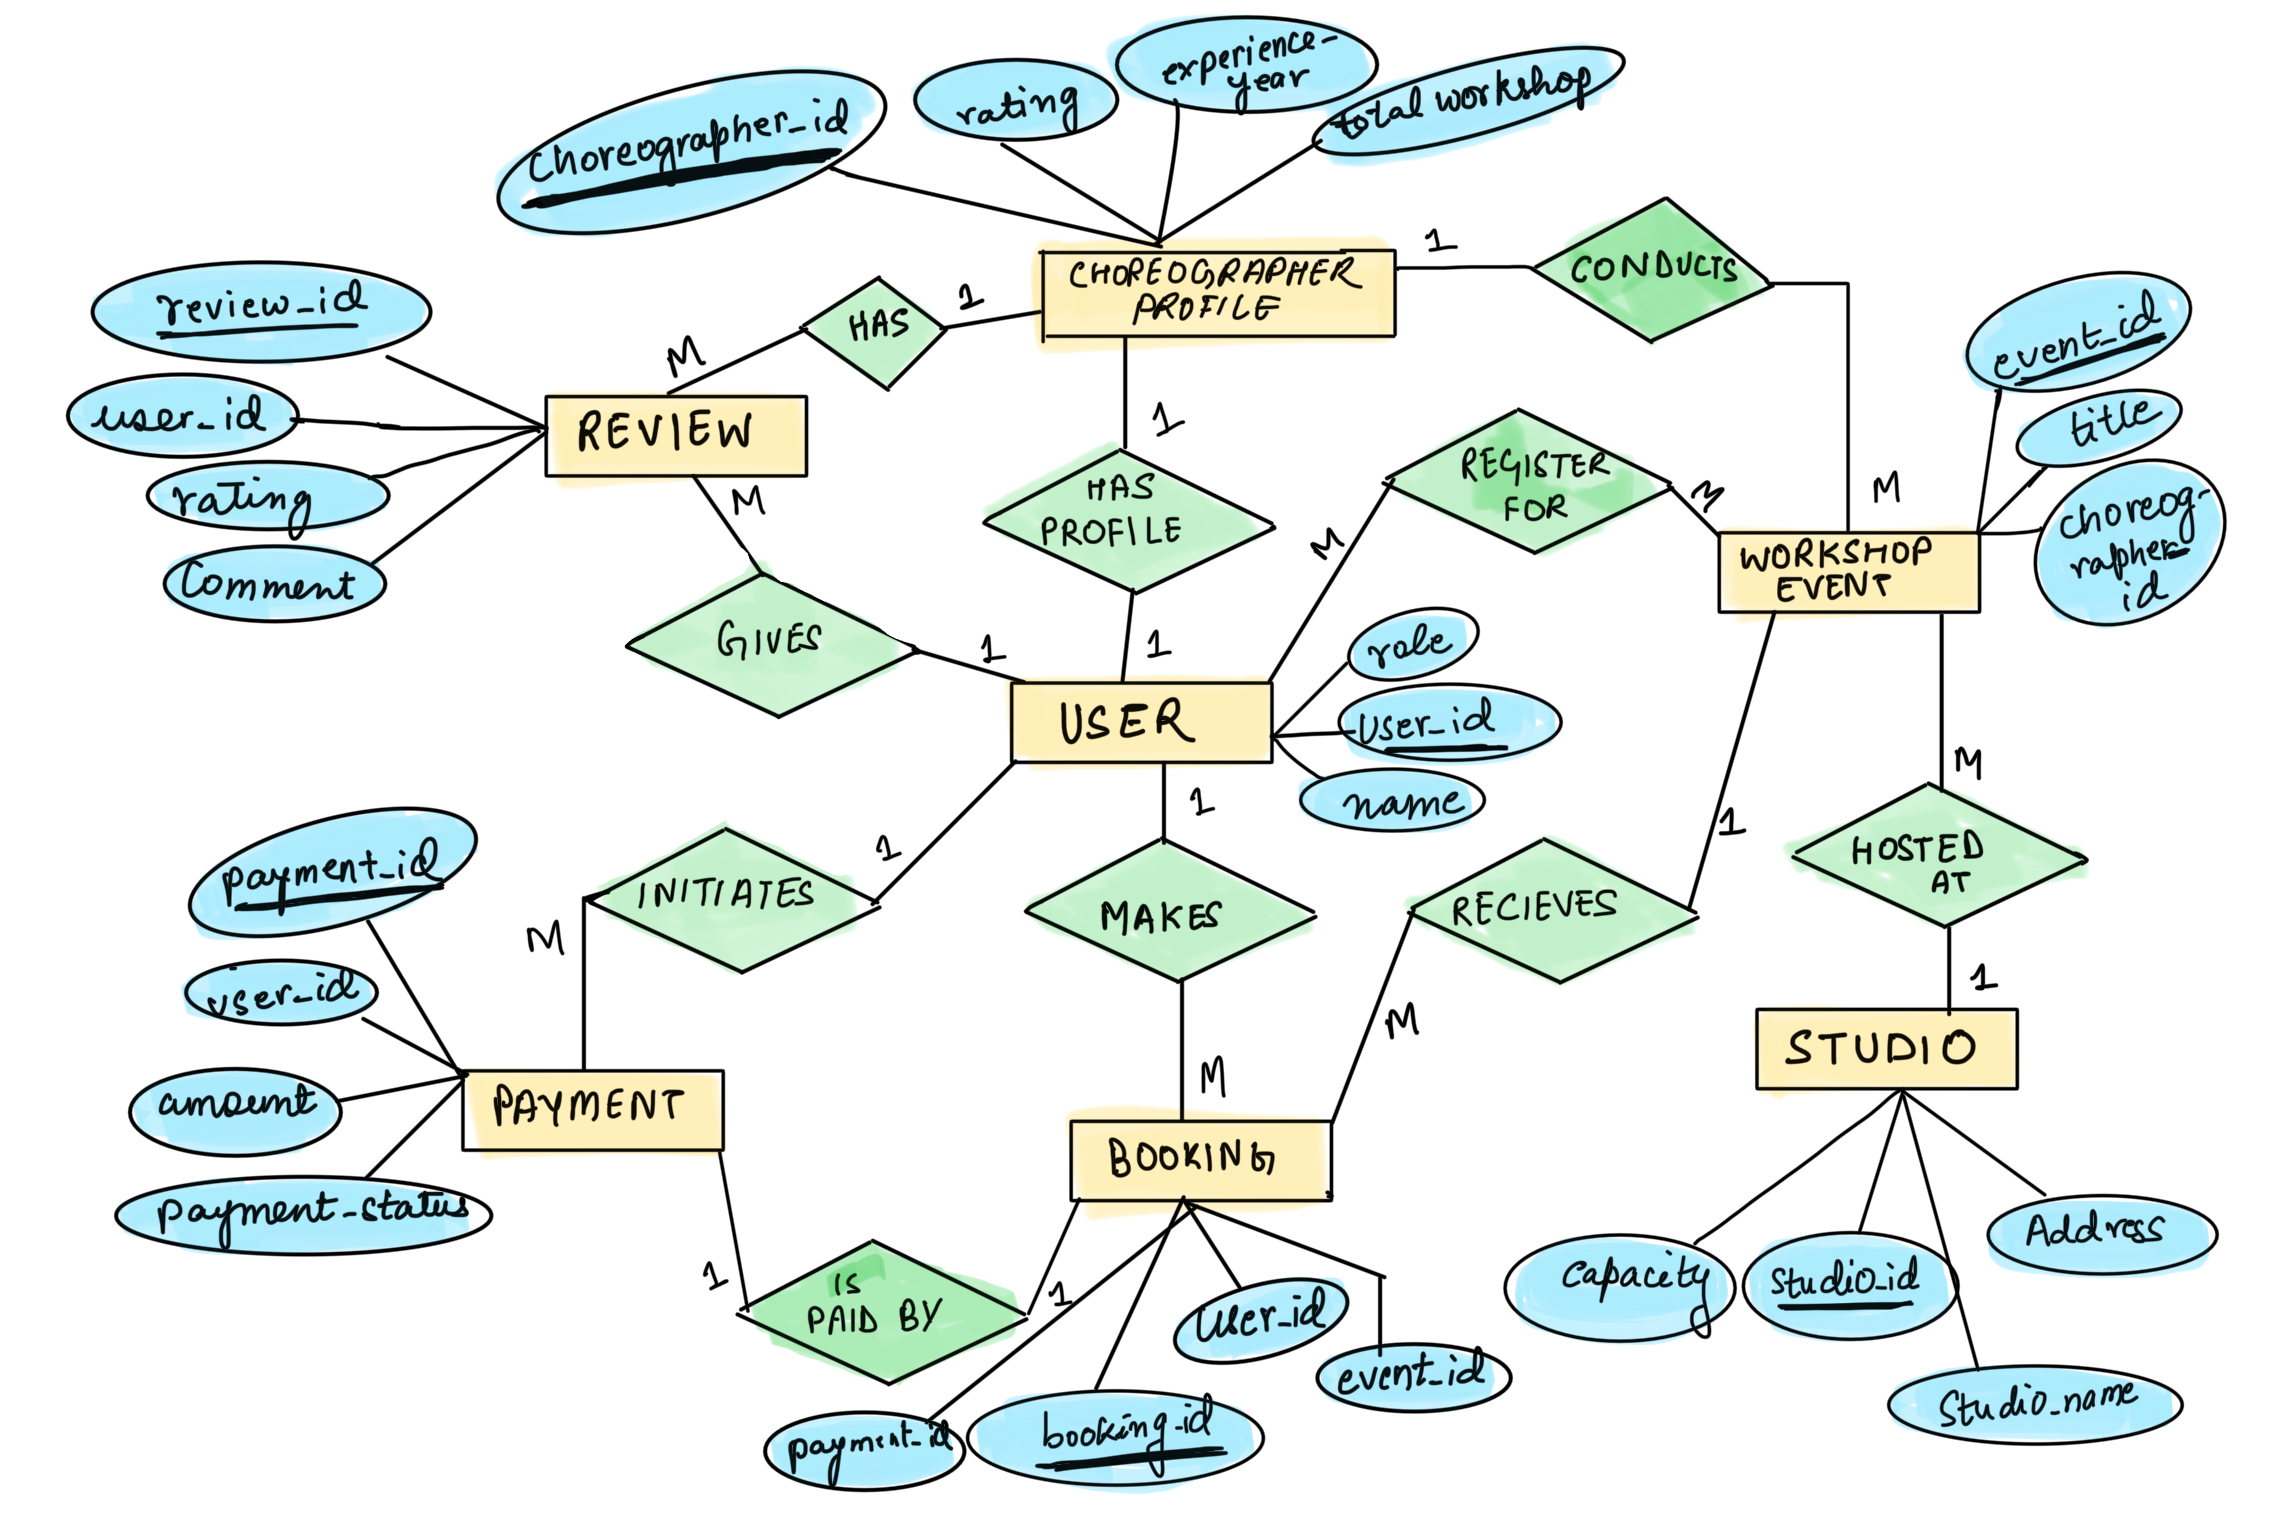

##3.6 Normal Forms

The schema is normalized up to Third Normal Form.
1. Each table has atomic attributes
2. No partial dependencies exists
3. Transitive dependencies are eliminated by separating entities like Studio, Payment, and ChoreographerProfile into their own tables.


#4.Implement your schema (DDL)

○ Add a sqlite database to your colab using the python sqlite3 library.

○ Create dataframes/tables for all of the tables in your schema with the appropriate columns/data types in your database.

○ Optional (1 pt extra credit):

■ Print out your schema (show each table name and what columns it has)

## 4.1 Adding sqlite database

In [ ]:
import sqlite3

In [ ]:
conn = sqlite3.connect("skillify.db")
cursor = conn.cursor()

##4.2 Creating tables

Using AUTOINCREMENT as SQLite guarantees:

1. IDs will never reuse deleted values
2. IDs always strictly increase

In [ ]:
# ----------------------
# USER TABLE
# ----------------------
cursor.execute("""
CREATE TABLE IF NOT EXISTS User (
    user_id INTEGER PRIMARY KEY AUTOINCREMENT,
    full_name TEXT NOT NULL,
    email TEXT UNIQUE NOT NULL,
    phone_number TEXT,
    password_hash TEXT NOT NULL,
    role TEXT CHECK(role IN ('student','choreographer','admin')) NOT NULL,
    bio TEXT,
    city TEXT,
    is_active INTEGER DEFAULT 1
);
""")

In [ ]:
# ----------------------
# CHOREOGRAPHER PROFILE (1:1 with User)
# ----------------------
cursor.execute("""
CREATE TABLE IF NOT EXISTS ChoreographerProfile (
    choreographer_id INTEGER PRIMARY KEY,
    experience_years INTEGER,
    instagram_url TEXT,
    average_rating REAL DEFAULT 0.0,
    total_workshops_hosted INTEGER DEFAULT 0,
    verified_status INTEGER DEFAULT 0,
    created_at TEXT,
    updated_at TEXT,
    FOREIGN KEY (choreographer_id)
        REFERENCES User(user_id)
        ON DELETE CASCADE
);
""")

In [ ]:
# ----------------------
# STUDIO TABLE
# ----------------------
cursor.execute("""
CREATE TABLE IF NOT EXISTS Studio (
    studio_id INTEGER PRIMARY KEY AUTOINCREMENT,
    studio_name TEXT NOT NULL,
    address_line_1 TEXT,
    city TEXT,
    capacity INTEGER,
    contact_phone TEXT,
    owner_user_id INTEGER,
    created_at TEXT,
    updated_at TEXT,
    FOREIGN KEY (owner_user_id)
        REFERENCES User(user_id)
);
""")

In [ ]:
# ----------------------
# WORKSHOP EVENT
# ----------------------
cursor.execute("""
CREATE TABLE IF NOT EXISTS WorkshopEvent (
    event_id INTEGER PRIMARY KEY AUTOINCREMENT,
    title TEXT NOT NULL,
    choreographer_id INTEGER,
    studio_id INTEGER,
    level TEXT CHECK(level IN ('beginner','intermediate','advanced')),
    price REAL,
    max_capacity INTEGER,
    current_bookings_count INTEGER DEFAULT 0,
    start_datetime TEXT,
    end_datetime TEXT,
    status TEXT CHECK(status IN ('upcoming','completed','cancelled')),
    created_at TEXT,
    updated_at TEXT,
    FOREIGN KEY (choreographer_id)
        REFERENCES ChoreographerProfile(choreographer_id),
    FOREIGN KEY (studio_id)
        REFERENCES Studio(studio_id)
);
""")

In [ ]:
# ----------------------
# BOOKING (M:M resolver)
# ----------------------
cursor.execute("""
CREATE TABLE IF NOT EXISTS Booking (
    booking_id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER,
    event_id INTEGER,
    booking_status TEXT CHECK(booking_status IN ('confirmed','cancelled','waitlisted')),
    ticket_type TEXT,
    booking_date TEXT,
    payment_id INTEGER UNIQUE,
    qr_code TEXT,
    attendance_status TEXT CHECK(attendance_status IN ('attended','no_show')),
    FOREIGN KEY (user_id)
        REFERENCES User(user_id),
    FOREIGN KEY (event_id)
        REFERENCES WorkshopEvent(event_id),
    FOREIGN KEY (payment_id)
        REFERENCES Payment(payment_id)
);
""")


In [ ]:
# ----------------------
# PAYMENT (1:1 with Booking)
# ----------------------
cursor.execute("""
CREATE TABLE IF NOT EXISTS Payment (
    payment_id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER,
    amount REAL,
    payment_method TEXT,
    payment_status TEXT CHECK(payment_status IN ('pending','successful','failed','refunded')),
    transaction_reference TEXT,
    payment_date TEXT,
    FOREIGN KEY (user_id)
        REFERENCES User(user_id)
);
""")

In [ ]:
# ----------------------
# REVIEW
# ----------------------
cursor.execute("""
CREATE TABLE IF NOT EXISTS Review (
    review_id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER,
    event_id INTEGER,
    rating INTEGER CHECK(rating BETWEEN 1 AND 5),
    comment TEXT,
    created_at TEXT,
    updated_at TEXT,
    FOREIGN KEY (user_id)
        REFERENCES User(user_id),
    FOREIGN KEY (event_id)
        REFERENCES WorkshopEvent(event_id),
    UNIQUE(user_id, event_id)
);
""")

In [ ]:
conn.commit()

##4.3 Printing the Tables

In [ ]:
# Get all table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

# Print table names and their columns
for table in tables:
    table_name = table[0]
    print(f"\nTable: {table_name}")

    cursor.execute(f"PRAGMA table_info({table_name});")
    columns = cursor.fetchall()

    for col in columns:
        print(" -", col[1])   # col[1] = column name


Table: User
 - user_id
 - full_name
 - email
 - phone_number
 - password_hash
 - role
 - bio
 - city
 - is_active

Table: sqlite_sequence
 - name
 - seq

Table: ChoreographerProfile
 - choreographer_id
 - experience_years
 - instagram_url
 - average_rating
 - total_workshops_hosted
 - verified_status
 - created_at
 - updated_at

Table: Studio
 - studio_id
 - studio_name
 - address_line_1
 - city
 - capacity
 - contact_phone
 - owner_user_id
 - created_at
 - updated_at

Table: WorkshopEvent
 - event_id
 - title
 - choreographer_id
 - studio_id
 - level
 - price
 - max_capacity
 - current_bookings_count
 - start_datetime
 - end_datetime
 - status
 - created_at
 - updated_at

Table: Booking
 - booking_id
 - user_id
 - event_id
 - booking_status
 - ticket_type
 - booking_date
 - payment_id
 - qr_code
 - attendance_status

Table: Payment
 - payment_id
 - user_id
 - amount
 - payment_method
 - payment_status
 - transaction_reference
 - payment_date

Table: Review
 - review_id
 - user_id
 - 

Table: sqlite_sequence
 - name
 - seq
`
This table appears if at least one table uses AUTOINCREMENT. It is automatically managed by SQLite

#**5. Create data (DML)**

○ Pretend you have had some real users/customers/whatever that have generated data in your previously created tables.

○ Write and execute SQL commands to insert at least 5 rows of fake data into each of your tables.

■ Make sure your pretend data makes sense, and each row has unique attribute
values where appropriate.


○ Update one of the attribute values for one of the rows in a table.


■ Show what it was before and what it is after your update using code.

In [ ]:
# Enable foreign keys (important in SQLite)
cursor.execute("PRAGMA foreign_keys = ON;")

In [ ]:
# ----------------------
# INSERT USERS
# ----------------------

cursor.executescript("""
INSERT INTO User (full_name, email, phone_number, password_hash, role, bio, city)
VALUES
('Aarav Sharma', 'aarav@email.com', '1111111111', 'hash1', 'student', 'Hip-hop enthusiast', 'New York'),
('Meera Kapoor', 'meera@email.com', '2222222222', 'hash2', 'student', 'Loves contemporary dance', 'Boston'),
('Rohan Mehta', 'rohan@email.com', '3333333333', 'hash3', 'choreographer', 'Bollywood expert', 'Chicago'),
('Sanya Verma', 'sanya@email.com', '4444444444', 'hash4', 'choreographer', 'Jazz & Ballet', 'San Francisco'),
('Admin User', 'admin@email.com', '5555555555', 'hash5', 'admin', 'Platform admin', 'Los Angeles');
""")



In [ ]:
# ----------------------
# INSERT CHOREOGRAPHER PROFILES
# ----------------------
cursor.executescript("""
INSERT INTO ChoreographerProfile
(choreographer_id, experience_years, instagram_url, verified_status, created_at)
VALUES
(3, 8, 'https://instagram.com/rohan_dance', 1, '2026-01-01'),
(4, 5, 'https://instagram.com/sanya_moves', 0, '2026-01-02');
""")

In [ ]:
# ----------------------
# INSERT STUDIOS
# ----------------------
cursor.executescript("""
INSERT INTO Studio (studio_name, address_line_1, city, capacity, contact_phone, owner_user_id, created_at)
VALUES
('Downtown Dance Hub', '123 Main St', 'Chicago', 50, '9991111111', 3, '2026-01-01'),
('Elite Dance Studio', '456 Park Ave', 'San Francisco', 40, '9992222222', 4, '2026-01-02'),
('Rhythm Space', '789 Broadway', 'New York', 35, '9993333333', 3, '2026-01-03'),
('Motion Arts', '321 Sunset Blvd', 'Los Angeles', 60, '9994444444', 4, '2026-01-04'),
('Urban Beats Studio', '654 Lake Shore', 'Chicago', 45, '9995555555', 3, '2026-01-05');
""")

In [ ]:

# ----------------------
# INSERT WORKSHOP EVENTS
# ----------------------
cursor.executescript("""
INSERT INTO WorkshopEvent
(title, choreographer_id, studio_id, level, price, max_capacity, start_datetime, end_datetime, status, created_at)
VALUES
('Bollywood Blast', 3, 1, 'beginner', 25.0, 50, '2026-02-20 10:00', '2026-02-20 12:00', 'upcoming', '2026-02-01'),
('Jazz Funk Fusion', 4, 2, 'intermediate', 30.0, 40, '2026-02-22 14:00', '2026-02-22 16:00', 'upcoming', '2026-02-02'),
('Hip-Hop Groove', 3, 3, 'advanced', 35.0, 35, '2026-02-25 18:00', '2026-02-25 20:00', 'upcoming', '2026-02-03'),
('Ballet Basics', 4, 4, 'beginner', 20.0, 60, '2026-03-01 09:00', '2026-03-01 11:00', 'upcoming', '2026-02-04'),
('Contemporary Flow', 4, 2, 'advanced', 40.0, 40, '2026-03-05 17:00', '2026-03-05 19:00', 'upcoming', '2026-02-05');
""")

In [ ]:
# ----------------------
# INSERT PAYMENTS
# ----------------------
cursor.executescript("""
INSERT INTO Payment (user_id, amount, payment_method, payment_status, transaction_reference, payment_date)
VALUES
(1, 25.0, 'card', 'successful', 'TXN001', '2026-02-10'),
(2, 30.0, 'upi', 'successful', 'TXN002', '2026-02-11'),
(1, 35.0, 'card', 'successful', 'TXN003', '2026-02-12'),
(2, 20.0, 'card', 'successful', 'TXN004', '2026-02-13'),
(1, 40.0, 'upi', 'pending', 'TXN005', '2026-02-14');
""")

In [ ]:
# ----------------------
# INSERT BOOKINGS
# ----------------------
cursor.executescript("""
INSERT INTO Booking (user_id, event_id, booking_status, ticket_type, booking_date, payment_id)
VALUES
(1, 1, 'confirmed', 'regular', '2026-02-10', 1),
(2, 2, 'confirmed', 'regular', '2026-02-11', 2),
(1, 3, 'confirmed', 'vip', '2026-02-12', 3),
(2, 4, 'confirmed', 'regular', '2026-02-13', 4),
(1, 5, 'waitlisted', 'regular', '2026-02-14', 5);
""")

In [ ]:
cursor.execute("SELECT booking_id, payment_id FROM Booking;")
print(cursor.fetchall())

[(1, 1), (2, 2), (3, 3), (4, 4), (5, 5)]


In [ ]:
# ----------------------
# INSERT REVIEWS
# ----------------------
cursor.executescript("""
INSERT INTO Review (user_id, event_id, rating, comment, created_at)
VALUES
(1, 1, 5, 'Amazing energy and choreography!', '2026-02-21'),
(2, 2, 4, 'Loved the vibe!', '2026-02-23'),
(1, 3, 5, 'Advanced moves were challenging but fun!', '2026-02-26'),
(2, 4, 3, 'Good for beginners.', '2026-03-02'),
(1, 5, 4, 'Great contemporary session!', '2026-03-06');
""")

In [ ]:
conn.commit()

##5.2 Updating the entry
Show what it was before and what it is after your update using code.

In [ ]:
# Suppose one of the
cursor.execute("""
SELECT user_id, full_name, city
FROM User
WHERE full_name = 'Aarav Sharma';
""")

print("Before Update:", cursor.fetchone())


cursor.execute("""
UPDATE User
SET city = 'Seattle'
WHERE full_name = 'Aarav Sharma';
""")

conn.commit()

cursor.execute("""
SELECT user_id, full_name, city
FROM User
WHERE full_name = 'Aarav Sharma';
""")

print("After Update:", cursor.fetchone())

Before Update: (1, 'Aarav Sharma', 'New York')
After Update: (1, 'Aarav Sharma', 'Seattle')


# 6.Query
○ Imagine that you now need to gain some intelligence from your data.

○ Choose 2-4 questions you might like to ask of the data (and of course write them in
your colab notebook).

○ Create and execute SQL queries that will answer these questions.

■ Make sure the query results are shown in your colab.

■ At least one of your queries should include a JOIN.

● Explain in words/text what your join is doing.

■ At least one of your queries should have a WHERE clause.

■ At least one of your queries should use an aggregate function.

● ex. AVG, COUNT, MAX, etc

■ At least one of your queries should use a GROUP BY.

○ Optional (1 pt extra credit):

■ Discuss how you might apply a more complex data science algorithm on top of
this data

Questions to ask :

1. What is the average number of bookings /participation for a workshop ?
2. What are the upcoming Events in Chicago ?
3. What events are happening on a specific date?
4. What is the total revenue per event ?
5. How to find the studio hosting most number of events?

### 1. What is the average number of confirmed bookings per event?

In [ ]:
import pandas as pd

query1 = """
SELECT AVG(booking_count) AS avg_confirmed_bookings
FROM (
    SELECT event_id, COUNT(*) AS booking_count
    FROM Booking
    WHERE booking_status = 'confirmed'
    GROUP BY event_id
);
"""

print("Average Confirmed Bookings Per Event")
print(pd.read_sql_query(query1, conn))


Average Confirmed Bookings Per Event
   avg_confirmed_bookings
0                     1.0


### 2. What are the upcoming Events in Chicago ?

This JOIN connects WorkshopEvent and Studio using studio_id so we can filter events based on the city stored in the Studio table.




In [ ]:
query2 = """
SELECT w.title, w.start_datetime, s.city
FROM WorkshopEvent w
JOIN Studio s ON w.studio_id = s.studio_id
WHERE s.city = 'Chicago' AND w.status = 'upcoming';
"""

print("Upcoming Events in Chicago")
print(pd.read_sql_query(query2, conn))


Upcoming Events in Chicago
             title    start_datetime     city
0  Bollywood Blast  2026-02-20 10:00  Chicago


### 3. What events are happening on a specific date?


In [ ]:
query3 = """
SELECT title, start_datetime
FROM WorkshopEvent
WHERE DATE(start_datetime) = '2026-02-20'
"""

print("Events happening on a specific date")
print(pd.read_sql_query(query3, conn))

Events happening on a specific date
             title    start_datetime
0  Bollywood Blast  2026-02-20 10:00


### 4. What is the total revenue per event ?


In [ ]:
query4 = """
SELECT w.title,
       SUM(p.amount) AS total_revenue
FROM WorkshopEvent w
JOIN Booking b ON w.event_id = b.event_id
JOIN Payment p ON b.payment_id = p.payment_id
WHERE p.payment_status = 'successful'
GROUP BY w.event_id;
"""
print("\n Total Revenue Per Event")
print(pd.read_sql_query(query5, conn))


 Total Revenue Per Event
              title  total_revenue
0   Bollywood Blast           25.0
1  Jazz Funk Fusion           30.0
2    Hip-Hop Groove           35.0
3     Ballet Basics           20.0


### 5.How to find the studios hosting the most number of events ?

In [ ]:
query5 = """
SELECT s.studio_name,
       COUNT(w.event_id) AS event_count
FROM Studio s
JOIN WorkshopEvent w ON s.studio_id = w.studio_id
GROUP BY s.studio_id
ORDER BY event_count DESC ;
"""

print("\nStudio Hosting the Most Number of Events")
print(pd.read_sql_query(query5, conn))


Studio Hosting the Most Number of Events
          studio_name  event_count
0  Elite Dance Studio            2
1         Motion Arts            1
2        Rhythm Space            1
3  Downtown Dance Hub            1


##6.2 Data Science Algorythm

A Personalized Recommendation System  :      

A personalized recommendation system could be built using collaborative filtering to suggest workshops based on user behavior.

-  By leveraging booking history, preferred event levels, cities attended, ratings given, and choreographers previously booked, we can construct a user–item matrix representing interactions between users and events.

- Techniques such as matrix factorization (e.g., SVD) can then identify hidden preference patterns.

- For example, if two users frequently attend advanced hip-hop workshops and one registers for a new jazz fusion session, the system can recommend that event to the other user.

This approach increases booking conversion rates, improves engagement, and enhances overall customer lifetime value.


#**7. Scale**
○ Now imagine your company, and therefore data, has grown too large for a lightweight
database like sqlite. What might be your next step up in scale (while still keeping the
data in a relational database)?

## 7.1

Imagine further that the data can no longer fit on a single machine/server running your database. How might you scale it (again, still keeping it as a relational database)?

■ What options do you have to scale your data?

■ What kinds of things might you need to weigh for your particular business?



1. If the data has grown , it can be high concurrent users, large transaction volumnes, complex queries then the data can no longer stay in the sqllite3. The next logical step would be to migrate it to database like PostgreSQL or MySQL. They have better concurrency control advanced indexing or replication and optimized query planning.

2. If the data outgrows, we can still use the relational database and scale it vertically by adding more RAM or SSD storage .

3. Further creating replicas and having eplicas handle queries will improve the read performance.

4. sharding or Horizontal partitioning will help in splitting data across multiple machines based on Users (A-M) and users (N-Z) .
OR we can shard based on the city or the user_id range .

5. Partitioning dataset based on date, city or the event_ids can help in faster querying.





## 7.2 TRADE-OFF:   


For a workshop platform like Skillify if most users are browsing events - replication is ideal . And if there is heavy booking traffic, one can do sharding or distributed SQL.


| Strategy         | Pros                      | Cons                         |
| ---------------- | ------------------------- | ---------------------------- |
| Vertical Scaling | Simple                    | Hardware limits              |
| Read Replicas    | Great for read-heavy apps | Write bottleneck remains     |
| Sharding         | Massive scale             | Complex joins & transactions |
| Partitioning     | Query performance boost   | Not true horizontal scale    |

